# Adaptive Generalized Dispersive Mode Decomposition (AGDMD / AGNCMD)

> Wang H., Chen S., Zhai W.  
> *Adaptive generalized dispersive mode decomposition: A data-driven approach for nonlinear dispersive component extraction in mechanical systems.*  
> Journal of Sound and Vibration, 2025.

## Idea

Classical **GDMD** needs hand-crafted initial group delays (GDs) and bandwidth
parameters. **AGDMD** makes the pipeline data-driven:

1. **AGDI** — adaptive GD initialisation (spectral IF-DN + TVLP, then decimate)
2. **BE** — bandwidth / $\alpha$ estimation via dispersion compensation
3. **Adaptive GDMD** — recursive single-mode extraction with non-increasing $\alpha$


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import AGNCMD
from pysdkit._gdmd.agncmd import make_agncmd_demo_signal, stft_agncmd
from pysdkit._gdmd.gdmd import tf_spec_from_gd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
print(AGNCMD())

Adaptive Generalized Dispersive Mode Decomposition (AGDMD / AGNCMD)


## 2. MATLAB `Example1.m` synthetic signal

Three close dispersive modes ($f_s=100\,$Hz, $T=10\,$s):

$$
\tau_k(f)=\frac{1}{125}f^2-\frac{2}{5}f+(6.5+0.5(k-1)),\quad k=1,2,3
$$

with amplitude envelope $e^{-0.02 f}$.


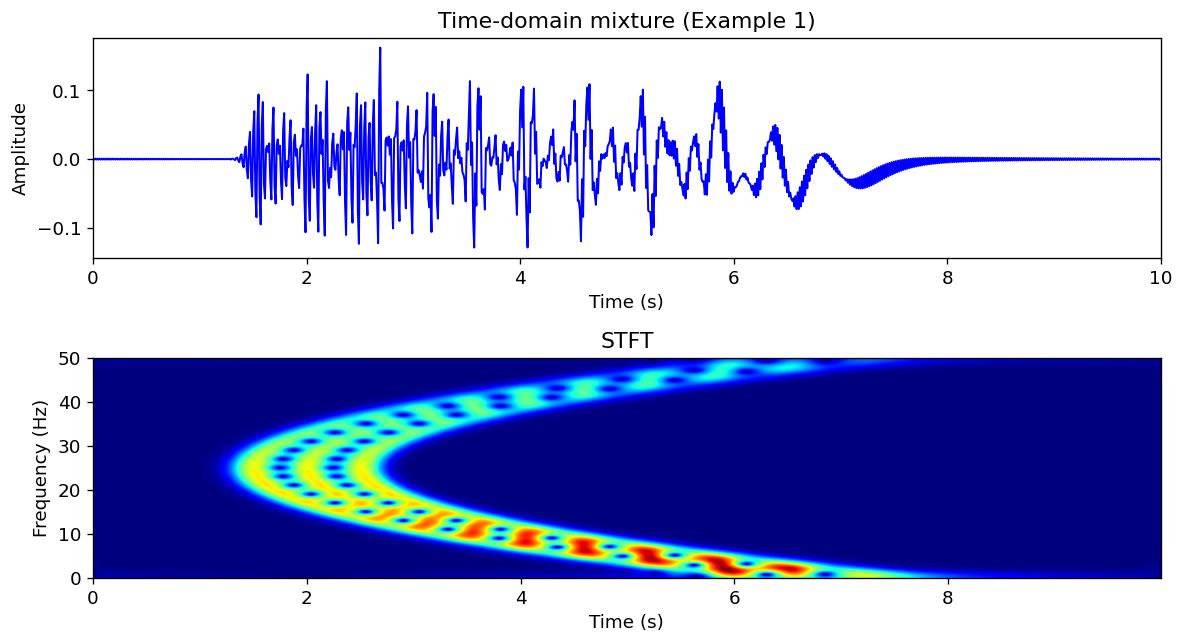

In [2]:
demo = make_agncmd_demo_signal(samp_freq=100.0, duration=10.0)
t = demo["t"]
x = demo["signal"]
f = demo["f"]
fs = float(demo["fs"][0])
true_gds = demo["true_gds"]
true_t = demo["true_modes_time"]
true_f = demo["true_modes_freq"]

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=False)
axes[0].plot(t, x, "b", lw=1.2)
axes[0].set_ylabel("Amplitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Time-domain mixture (Example 1)")
axes[0].set_xlim(0, 10)

spec, f_stft = stft_agncmd(x, fs, n_freq=1002, win_len=108)
axes[1].imshow(
    spec,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], f_stft[0], f_stft[-1]],
    cmap="jet",
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("STFT")
axes[1].set_ylim(0, 50)
fig.tight_layout()
plt.show()

## 3. Run AGNCMD

```matlab
beta = 1e-7;
[f, IGD, EGD, modef, modet, alpha] = AGDMD(Sig, SampFreq, beta);
```


In [3]:
decomp = AGNCMD(beta=1e-7, max_modes=3, max_iter=200)
modes_t, freq, igd, egd, modes_f, alphas = decomp.fit_transform(x, fs, return_all=True)

print("modes:", modes_t.shape)
print(
    "reconstruction ‖x − Σm − r‖ =",
    np.linalg.norm(x - modes_t.sum(0) - decomp.residual_),
)

for k in range(modes_t.shape[0]):
    corrs = [abs(float(np.corrcoef(true_t[j], modes_t[k])[0, 1])) for j in range(3)]
    j = int(np.argmax(corrs))
    print(f"  est mode {k+1} ↔ true m{j+1}: |corr|={corrs[j]:.4f}")

for k in range(egd.shape[0]):
    maes = [float(np.mean(np.abs(egd[k] - true_gds[j]))) for j in range(3)]
    j = int(np.argmin(maes))
    c = abs(float(np.corrcoef(egd[k], true_gds[j])[0, 1]))
    print(f"  EGD{k+1} ↔ true gd{j+1}: mae={maes[j]:.4f}, |corr|={c:.4f}")

modes: (3, 1000)
reconstruction ‖x − Σm − r‖ = 8.782004343183549e-17
  est mode 1 ↔ true m1: |corr|=0.9889
  est mode 2 ↔ true m3: |corr|=0.9045
  est mode 3 ↔ true m2: |corr|=0.8826
  EGD1 ↔ true gd1: mae=0.0410, |corr|=0.9946
  EGD2 ↔ true gd3: mae=0.0768, |corr|=0.9932
  EGD3 ↔ true gd2: mae=0.0747, |corr|=0.9964


### 3.1 Frequency-domain modes vs ground truth


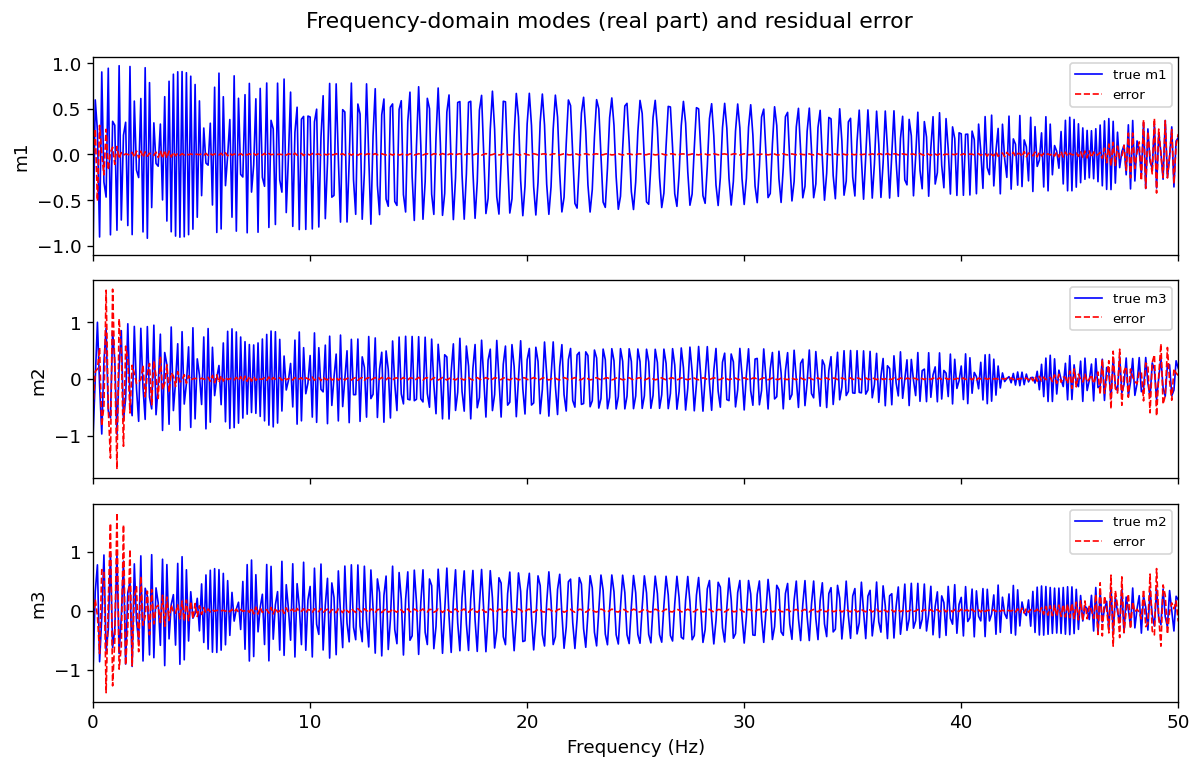

In [4]:
def match_by_gd(egd_row, true_gds):
    maes = [
        float(np.mean(np.abs(egd_row - true_gds[j]))) for j in range(true_gds.shape[0])
    ]
    return int(np.argmin(maes))


fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
for k, ax in enumerate(axes):
    j = match_by_gd(egd[k], true_gds)
    ax.plot(freq, np.real(true_f[j]), "b-", lw=1.0, label=f"true m{j+1}")
    ax.plot(freq, np.real(true_f[j] - modes_f[k]), "r--", lw=1.0, label="error")
    ax.set_ylabel(f"m{k+1}")
    ax.set_xlim(0, 50)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Frequency-domain modes (real part) and residual error")
fig.tight_layout()
plt.show()

### 3.2 Time-domain modes vs ground truth


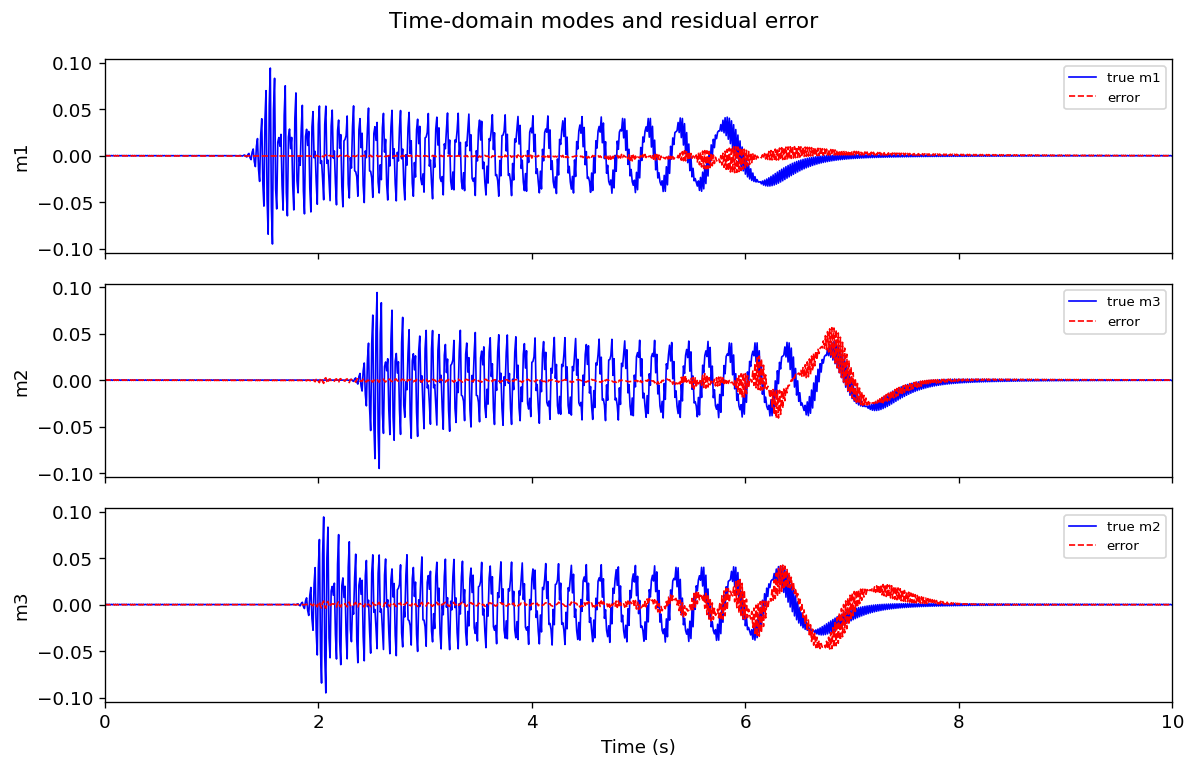

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
for k, ax in enumerate(axes):
    j = match_by_gd(egd[k], true_gds)
    ax.plot(t, true_t[j], "b-", lw=1.0, label=f"true m{j+1}")
    ax.plot(t, true_t[j] - modes_t[k], "r--", lw=1.0, label="error")
    ax.set_ylabel(f"m{k+1}")
    ax.set_xlim(0, 10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Time-domain modes and residual error")
fig.tight_layout()
plt.show()

### 3.3 Group delays: true / initial / estimated


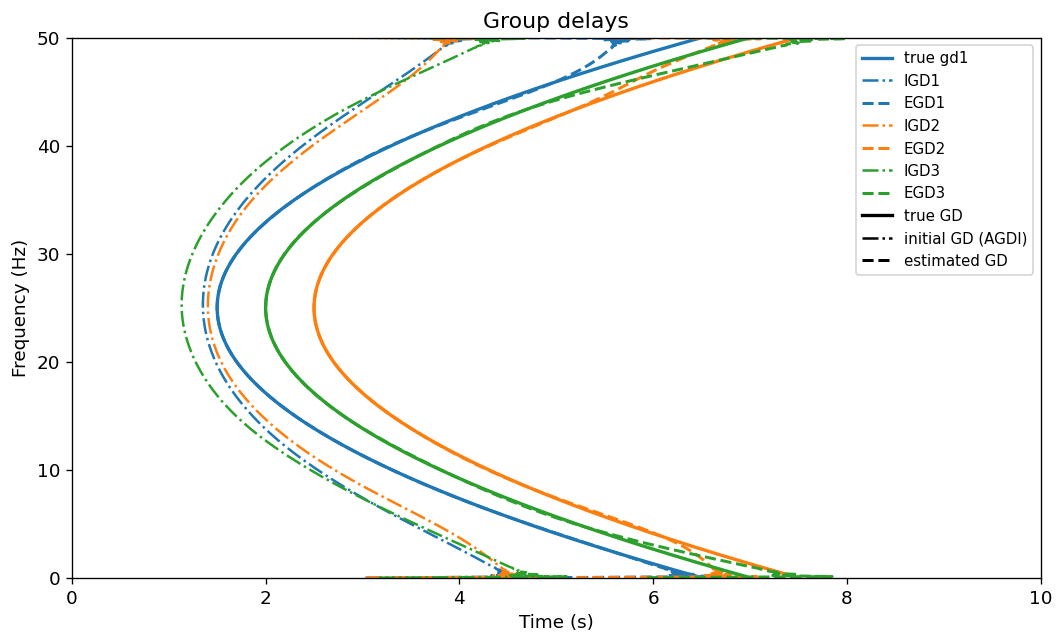

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["C0", "C1", "C2"]
for k in range(3):
    j = match_by_gd(egd[k], true_gds)
    ax.plot(
        true_gds[j],
        freq,
        colors[k] + "-",
        lw=2.0,
        label=f"true gd{j+1}" if k == 0 else None,
    )
    ax.plot(igd[k], freq, colors[k] + "-.", lw=1.5, label=f"IGD{k+1}")
    ax.plot(egd[k], freq, colors[k] + "--", lw=1.8, label=f"EGD{k+1}")
# cleaner legend: one true curve style note
ax.plot([], [], "k-", lw=2, label="true GD")
ax.plot([], [], "k-.", lw=1.5, label="initial GD (AGDI)")
ax.plot([], [], "k--", lw=1.8, label="estimated GD")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 50)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Group delays")
fig.tight_layout()
plt.show()

### 3.4 Adaptive bandwidth parameter $\alpha$


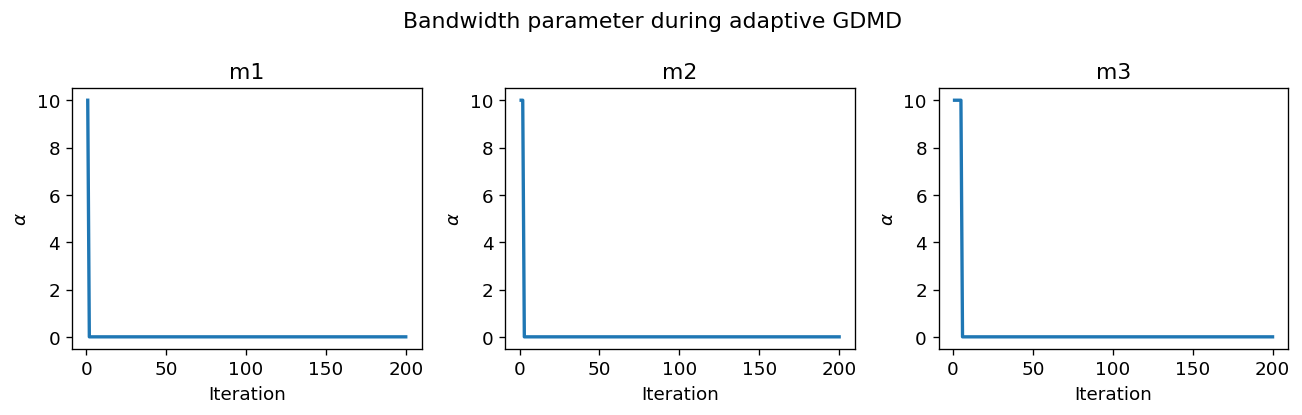

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=False)
for k, ax in enumerate(axes):
    ax.plot(1 + np.arange(len(alphas[k])), alphas[k], lw=2)
    ax.set_title(f"m{k+1}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\alpha$")
fig.suptitle("Bandwidth parameter during adaptive GDMD")
fig.tight_layout()
plt.show()

### 3.5 TF image from estimated GDs


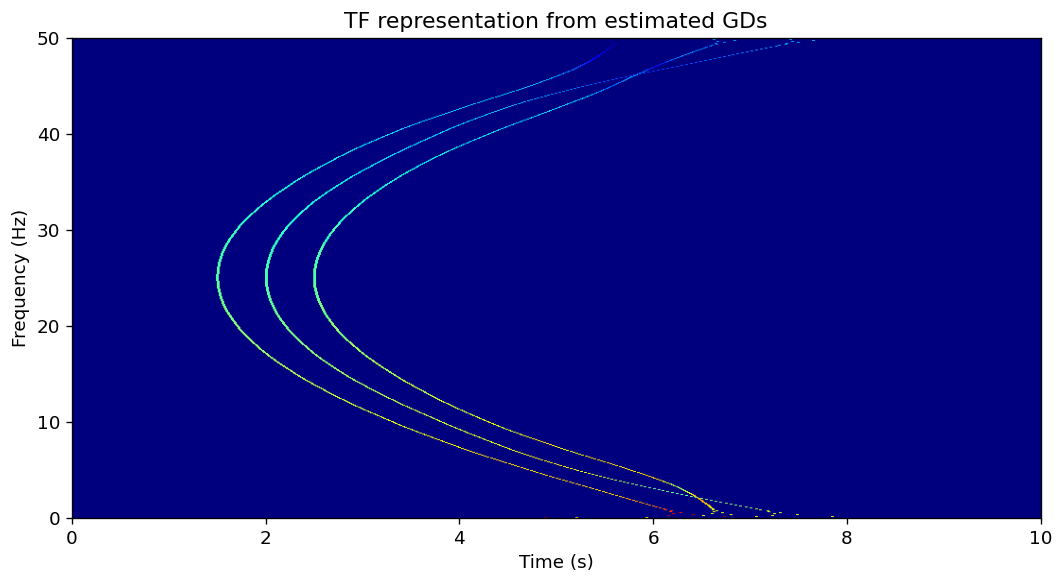

In [8]:
a_spec, t_bins = tf_spec_from_gd(egd, np.abs(modes_f), (0.0, 10.0), n_time_bins=1024)
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(
    np.abs(a_spec),
    aspect="auto",
    origin="lower",
    extent=[t_bins[0], t_bins[-1], freq[0], freq[-1]],
    cmap="jet",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 50)
ax.set_title("TF representation from estimated GDs")
fig.tight_layout()
plt.show()

## 4. Quick API

```python
from pysdkit import AGNCMD, AGDMD  # AGDMD is an alias

modes = AGNCMD(beta=1e-7, max_modes=3)(signal, fs)
modes, f, igd, egd, modes_f, alphas = AGNCMD()(signal, fs, return_all=True)
```

| MATLAB | PySDKit |
|---|---|
| `AGDMD(Sig, SampFreq, beta)` | `AGNCMD(beta=...)(Sig, fs, return_all=True)` |
| `max_modes` / `Kmax=3` | `max_modes=3` |
| outputs `f, IGD, EGD, modef, modet, alpha` | `modes_t, f, IGD, EGD, modes_f, alphas` |
